<a href="https://colab.research.google.com/github/rdsmaia/dim0494/blob/main/imdb_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install -U datasets huggingface_hub fsspec

  Using cached fsspec-2025.5.1-py3-none-any.whl.metadata (11 kB)


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset, random_split
from datasets import load_dataset
from transformers import BertTokenizer
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

In [3]:
class IMDBDataset(Dataset):
  """
  IMDB dataset
  """
  def __init__(self, split='train', max_length=512):

    # load dataset
    self.dataset = load_dataset("imdb")[split]

    # tokenizer
    self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    # max sequence length (max context)
    self.max_length = max_length

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):

    # text
    text = self.dataset[idx]['text']

    # label
    label = self.dataset[idx]['label']

    # tokenizer processing output
    encoding = self.tokenizer(text,
                              truncation=True,
                              padding='max_length',
                              max_length=self.max_length,
                              return_token_type_ids=False,
                              return_attention_mask=True,
                              return_tensors='pt')
    # output
    return {
        'input_ids': encoding['input_ids'].flatten(),
        'attention_mask': encoding['attention_mask'].flatten(),
        'label': torch.tensor(label, dtype=torch.long)
    }

In [4]:
class SentimentClassifier(nn.Module):
  """
  Sentiment classifier model using recurrent layers.
  """
  def __init__(self,
               vocab_size,
               embedding_dim,
                                                                                                                                                                                                                                                                                                                                                                                                                                             hidden_dim,
               n_layers,
               dropout):

    super().__init__()

    # embedding layer
    self.embedding = nn.Embedding(vocab_size, embedding_dim)

    # LSTM layer
    self.lstm = nn.LSTM(embedding_dim,
                        hidden_dim,
                        num_layers=n_layers,
                        dropout=dropout,
                        bidirectional=True,
                        batch_first=True)

    # first dense layer
    self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)

    # second dense layer
    self.fc2 = nn.Linear(hidden_dim, 1)

    # dropout
    self.dropout = nn.Dropout(dropout)

  def forward(self, tokens, attention_mask=None):

    # get embeddings
    embedded = self.embedding(tokens)

    # LSTM layer
    lstm_out, (hidden_state, cell_state) = self.lstm(embedded)

    # context
    hidden = torch.cat((hidden_state[-2, :, :], hidden_state[-1, :, :]), dim=1)

    # dense layer 1: Leaky ReLU activation
    fc1_out = self.fc1(hidden)
    fc1_out = self.dropout(fc1_out)
    fc1_out = nn.functional.leaky_relu(fc1_out, 0.3)

    # dense layer 2
    output = self.fc2(fc1_out)
    y_hat = nn.functional.sigmoid(output)

    return y_hat

In [5]:
# hyperparametrers
batch_size = 32
num_epochs = 10
learning_rate = 0.001
hidden_dim = 32
n_layers = 1
dropout = 0.5
embedding_dim = 128

In [6]:
# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [7]:
# load train and test datasets
train_dataset = IMDBDataset(split='train')
test_dataset = IMDBDataset(split='test')

print(f'Size of the training dataset: {len(train_dataset)}\n')
print(f'Size of the testing dataset (before): {len(test_dataset)}\n')

# split test dataset into test and validation
test_size = int(0.5 * len(test_dataset))
val_size = len(test_dataset) - test_size

# Split
val_dataset, test_dataset = random_split(
    test_dataset,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # For reproducibility
)

print(f'Size of the validation dataset: {len(val_dataset)}\n')
print(f'Size of the testing dataset (after): {len(test_dataset)}\n')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Size of the training dataset: 25000

Size of the testing dataset (before): 25000

Size of the validation dataset: 12500

Size of the testing dataset (after): 12500



In [8]:
# tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print(f'Vocab size: {tokenizer.vocab_size}\n')
print(f'Special tokens: {tokenizer.special_tokens_map}\n')

Vocab size: 30522

Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}



In [9]:
# load model
model = SentimentClassifier(vocab_size=tokenizer.vocab_size,
                             embedding_dim=embedding_dim,
                             hidden_dim=hidden_dim,
                             n_layers=n_layers,
                             dropout=dropout).to(device)
print(model)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


SentimentClassifier(
  (embedding): Embedding(30522, 128)
  (lstm): LSTM(128, 32, batch_first=True, dropout=0.5, bidirectional=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [10]:
# optimizer
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate,
                       betas=(0.9, 0.999),
                       eps=1e-08)

# loss criterion: binary cross entropy
criterion = nn.BCELoss()

In [15]:
def train_model(model,
                train_dataset,
                val_dataset,
                batch_size,
                optmizer,
                num_epochs,
                learning_rate):

  # train and val loaders
  train_loader = DataLoader(train_dataset,
                            batch_size=batch_size,
                            shuffle=True)
  val_loader = DataLoader(val_dataset,
                          batch_size=batch_size,
                          shuffle=False)
  # history accumulation
  history = {
      'train_loss': [],
      'train_acc': [],
      'val_loss': [],
      'val_acc': []
  }

  # epoch loop
  for epoch in range(num_epochs):

    model.train()

    train_loss = 0
    correct_predictions = 0
    best_val_acc = 0.0

    # batch loop
    for batch in tqdm(train_loader, desc="Training"):

      # get batch of data
      tokens = batch['input_ids'].to(device)
      labels = batch['label'].to(device)

      # zero gradients
      optmizer.zero_grad()

      # output prediction
      y_hat = model(tokens)

      # cost
      loss = criterion(y_hat, labels.unsqueeze(1).float())

      # back prop
      loss.backward()

      # weight update
      optmizer.step()

      # accumulatre error
      train_loss += loss.item()

      # accuracy
      predicted_labels = (y_hat > 0.5).int().squeeze()
      correct_predictions += (predicted_labels == labels).sum().item()

    # get average losses per batch
    train_loss /= len(train_loader)
    train_acc = correct_predictions / len(train_dataset)

    # validation
    model.eval()

    with torch.no_grad():

      val_loss = 0
      correct_predictions = 0

      for batch in tqdm(val_loader, desc='Validation...'):
        # tokens and labels
        tokens = batch['input_ids'].to(device)
        labels = batch['label'].to(device)

        # predicted output
        y_hat = model(tokens)

        # loss
        loss = criterion(y_hat, labels.unsqueeze(1).float())
        val_loss += loss.item()

        # correctly predicted
        predicted_labels = (y_hat > 0.5).int().squeeze()
        correct_predictions += (predicted_labels == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = correct_predictions / len(val_loader.dataset)

    # save best checkpoint
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), 'best_model.pth')

    print(f'Epoch {epoch+1}/{num_epochs} | Train loss {train_loss:.4f} | Train Acc {train_acc:.4f} | Val Loss {val_loss:.4f} | Val Acc{val_acc:.4f}')

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

  return history

In [16]:
history = train_model(model=model,
                      train_dataset=train_dataset,
                      val_dataset=val_dataset,
                      batch_size=batch_size,
                      optmizer=optimizer,
                      num_epochs=num_epochs,
                      learning_rate=learning_rate)

Validation...: 100%|██████████| 391/391 [00:57<00:00,  6.76it/s]


Epoch 1/10 | Train loss 0.5392 | Train Acc 0.7439 | Val Loss 0.5700 | Val Acc0.7270


Validation...: 100%|██████████| 391/391 [00:57<00:00,  6.78it/s]


Epoch 2/10 | Train loss 0.4515 | Train Acc 0.8041 | Val Loss 0.5091 | Val Acc0.7730


Validation...: 100%|██████████| 391/391 [00:57<00:00,  6.77it/s]


...

Epoch 8/10 | Train loss 0.1342 | Train Acc 0.9530 | Val Loss 0.6950 | Val Acc0.7960


Validation...: 100%|██████████| 391/391 [00:58<00:00,  6.73it/s]


Epoch 9/10 | Train loss 0.1389 | Train Acc 0.9520 | Val Loss 0.7442 | Val Acc0.7849


Validation...: 100%|██████████| 391/391 [00:57<00:00,  6.74it/s]

Epoch 10/10 | Train loss 0.0860 | Train Acc 0.9715 | Val Loss 0.8819 | Val Acc0.8018


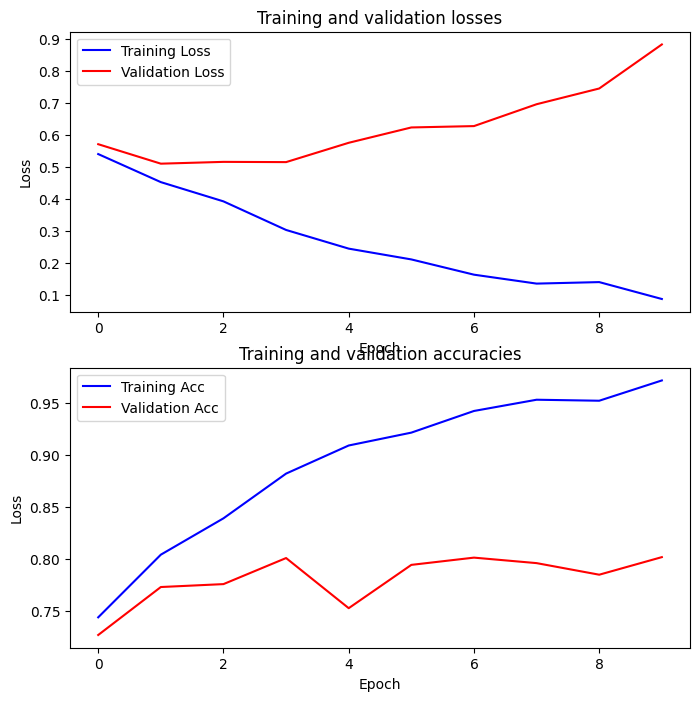

In [19]:
# plot losses and accuracy
loss_values = history['train_loss']
val_loss_values = history['val_loss']

# accuracies
accuracies = history['train_acc']
val_accuracies = history['val_acc']

epochs = range(len(accuracies))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))

ax1.plot(epochs, loss_values, 'b', label='Training Loss')
ax1.plot(epochs, val_loss_values, 'r', label='Validation Loss')
ax1.set_title('Training and validation losses')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, accuracies, 'b', label='Training Acc')
ax2.plot(epochs, val_accuracies, 'r', label='Validation Acc')
ax2.set_title('Training and validation accuracies')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()


In [25]:
# test model

# load model
model.load_state_dict(torch.load('best_model.pth'))
model = model.to(device)

def test_model(model, test_dataset, batch_size):
  """
  Function to test the model.
  """
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

  model.eval()
  test_loss = 0.0
  correct_predictions = 0
  all_labels = []
  all_outputs = []

  for batch in tqdm(test_loader, desc='Testing...'):

    # tokens and labels
    tokens = batch['input_ids'].to(device)
    labels = batch['label'].to(device)

    # predicted output
    y_hat = model(tokens)

    # loss
    loss = criterion(y_hat, labels.unsqueeze(1).float())
    test_loss += loss.item()

    # correct predictions
    predicted_labels = (y_hat > 0.5).int().squeeze()
    correct_predictions += (predicted_labels == labels).sum().item()

    # append labels and outputs
    all_labels.append(labels.cpu().numpy())
    all_outputs.append(y_hat.cpu().detach().numpy())

  # test loss: average
  test_loss /= len(test_loader)
  test_acc = correct_predictions / len(test_dataset)

  return {
      'loss': test_loss,
      'acc': test_acc,
      'labels': all_labels,
      'outputs': all_outputs
  }

# test loss
out = test_model(model, test_dataset, batch_size)
print(f'Test Loss: {out["loss"]:.4f} | Test Acc: {out["acc"]:.4f}')


Testing...: 100%|██████████| 391/391 [00:57<00:00,  6.84it/s]

Test Loss: 0.9468 | Test Acc: 0.7987


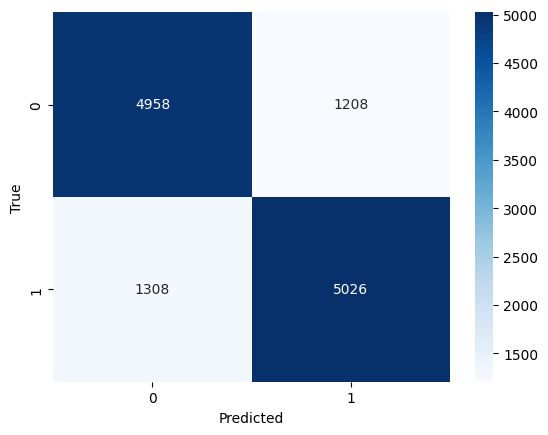

In [42]:
# make confusion matrix
all_labels = np.concatenate(out['labels'])
all_outputs = np.concatenate(out['outputs']).squeeze()
cm = confusion_matrix(all_labels, np.array((all_outputs) > 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [64]:
# test one sentence
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
max_length = 512

def predict_sentiment(model, tokenizer, sentence, max_length=512, device=device):
  model.eval()
  tokens = tokenizer(sentence,
                             truncation=True,
                             padding='max_length',
                             max_length=max_length,
                             return_token_type_ids=False,
                             return_attention_mask=True,
                             return_tensors='pt').input_ids
  tokens = tokens.to(device).reshape(1, -1)
  y_hat = model(tokens)
  print(f'Prediction (probability of positive): {y_hat.item():.4f}')
  predicted_label = (y_hat > 0.5).int().squeeze()
  if predicted_label == 1:
    predicted_label = "Positive"
  else:
    predicted_label = "Negative"
  print(f'Predicted sentiment: {predicted_label}')
  return

In [65]:
predict_sentiment(model, tokenizer, "This movie sucked big time!")

Prediction (probability of positive): 0.0049
Predicted sentiment: Negative
